### Import thư viện

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### LOAD & PREPROCESS DATA

In [2]:
df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['date'] = df['order_purchase_timestamp'].dt.date

daily_df = df.groupby('date')['payment_value'].sum().reset_index()
daily_df.columns = ['date', 'daily_revenue']
daily_df['date'] = pd.to_datetime(daily_df['date'])


In [3]:
## FEATURE ENGINEERING 

In [4]:
daily_df['day_of_week'] = daily_df['date'].dt.dayofweek
daily_df['month'] = daily_df['date'].dt.month
daily_df['day_of_month'] = daily_df['date'].dt.day
daily_df['is_weekend'] = daily_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


In [5]:
## TEST SET (30 NGÀY CUỐI)

In [6]:
test_size = 30
test_df = daily_df.iloc[-test_size:]

# Tách dữ liệu cho LR & XGBoost
X_test = test_df[['day_of_week', 'month', 'day_of_month', 'is_weekend']]
y_test = test_df['daily_revenue']

# Tách dữ liệu cho Prophet
prophet_test = test_df[['date']].rename(columns={'date': 'ds'})



In [7]:
## LOAD MODELS

In [8]:
# Lưu ý: Đảm bảo các file pkl này vừa được chạy lại từ 03a, 03b, 03c
lr_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\linear_model.pkl", "rb"))
xgb_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\xgboost_model.pkl", "rb"))
# Load mô hình Prophet dùng để test (đã nói ở phần trước)
prophet_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model.pkl", "rb"))


In [9]:
## PREDICT

In [10]:
y_pred_lr = lr_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_prophet = prophet_model.predict(prophet_test)['yhat'].values



In [11]:
## METRICS

In [12]:
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return round(mae, 2), round(rmse, 2), round(r2, 4)

metrics_lr = get_metrics(y_test, y_pred_lr)
metrics_xgb = get_metrics(y_test, y_pred_xgb)
metrics_prophet = get_metrics(y_test, y_pred_prophet)


In [13]:
## COMPARISON TABLE

In [14]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Facebook Prophet"],
    "MAE": [metrics_lr[0], metrics_xgb[0], metrics_prophet[0]],
    "RMSE": [metrics_lr[1], metrics_xgb[1], metrics_prophet[1]],
    "R2 Score": [metrics_lr[2], metrics_xgb[2], metrics_prophet[2]]
})

print("📊 BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH (Dự báo mù 30 ngày):")
display(results)



📊 BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH (Dự báo mù 30 ngày):


,Model,MAE,RMSE,R2 Score
0,Linear Regression,12016.65,14528.93,-0.1136
1,XGBoost,8610.58,10962.35,0.3660
2,Facebook Prophet,11607.09,14190.19,-0.0623


In [15]:
## VISUALIZATION

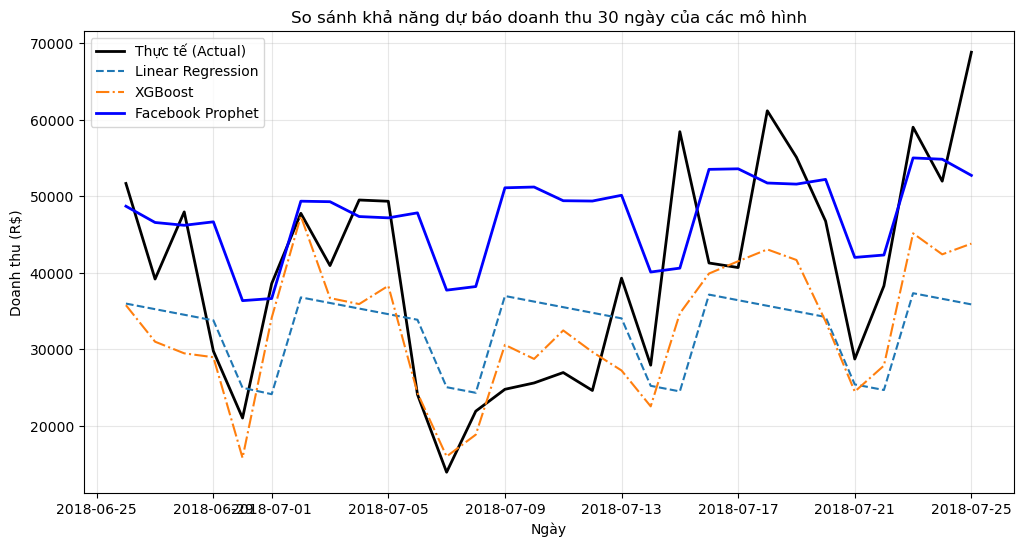

In [16]:
plt.figure(figsize=(12,6))
plt.plot(test_df['date'], y_test, label='Thực tế (Actual)', color='black', linewidth=2)
plt.plot(test_df['date'], y_pred_lr, label='Linear Regression', linestyle='--')
plt.plot(test_df['date'], y_pred_xgb, label='XGBoost', linestyle='-.')
plt.plot(test_df['date'], y_pred_prophet, label='Facebook Prophet', color='blue', linewidth=2)
plt.title("So sánh khả năng dự báo doanh thu 30 ngày của các mô hình")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu (R$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
